In [1]:
import math
import time 
import random
from glob import glob
import mappings as maps
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.spatial.distance import hamming
from sbox import Sbox
import ciphers
import os
import mappings as maps
from PIL import Image

# Binarization

In [ ]:
source_dir = "/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/misc"
imgsfiles = list(set(glob(source_dir+"/*")))# - set(glob(source_dir+"/*.rtf")))

for file in imgsfiles:
        if os.path.isfile(file):
                imgg = Image.open(file).convert('L')
                fname = file.split('/')[-1]
                fname = fname.split('.')[0]
                saveroute = source_dir+'/BW'+fname+'.png'
                imgg.save(saveroute,format='PNG')
        

In [2]:
def logist_generate_sbox(x01,x02,r1,r2,delay=10,sblen=256):
    startT = time.time()
    x1 = [x01]
    x2 = [x02]
    m1_seq = 0
    m2_seq = 0
    delayhf = int(delay*0.5)
    sb = []

    i = 0
    while len(sb) < sblen:
        x1.append(maps.logistic(x1[i],r1)) #x1(n+1)=f(x1(n))
        x2.append(maps.logistic(x2[i],r2))

        if i>= delay+1:
            m1_seq = (x1[int(i-(delay))]+x1[int(i-(delayhf))]+x1[int(i)])%256
            m2_seq = (x2[int(i-(delay))]+x2[int(i-(delayhf+1))]+x2[int(i)])%256
            Zi = math.floor((m1_seq+m2_seq)%256)
            if Zi not in sb: sb.append(Zi)

        i+=1
    
    print(sb)
    endT = time.time()
    # print("Time:")
    # print(endT - startT)
    # print("End, rotcont:")
    return sb

def alberti_cipher(image):
    arr = np.array(image)
    n = arr.shape[0]
    m = arr.shape[1]
    
    encode_arr = np.zeros((n,m))
    encode_arr2 = np.zeros((n,m))

    for i in range(n):
        x01,x02 = np.random.uniform(0,255),np.random.uniform(0,255)
        m1_params = np.random.random_integers(8000,9999,2)/10000
        m2_params = np.random.random_integers(2000,10000,2)/1000
        b1_params = np.random.random_integers(25000,50000,2)/1000
        func1 = [m1_params[0],m2_params[0],b1_params[0]]
        func2 = [m1_params[1],m2_params[1],b1_params[1]]
        sb,zet = ciphers.generate_sbox(x01,x02,10,func1,func2)
        sbsplit = np.vstack(np.array_split(sb,16))
        chsize = len(zet)
        # print(f'Len chaos: {chsize}, Cols: {m}')
        # print(f'times repeated: {m//chsize}')
        newzet = zet*((m//chsize)+1)
        # print(f'newsize chaos: {newzet}')
        # print(len(newzet),m)
        for j in range(m):    
            srow,scol = int(np.floor(arr[i,j]/16)),int(arr[i,j]-np.floor(arr[i,j]/16)*16)
            encode_arr2[i,j] = sbsplit[srow,scol]
            sbpixbin = bin(int(encode_arr2[i,j]))[2:].zfill(8)
            zetbin = bin(int(newzet[j]))[2:].zfill(8)
            a = list(map(int, sbpixbin))
            b = list(map(int, zetbin))
            distHam = hamming(a,b)*8
            if distHam<4:
                dshift = int(distHam+1)
                # print(a)
                a = a[-dshift:]+a[:-dshift]
                # print(a)
            else:
                dshift = int(8-distHam)
                # print(a)
                a = a[dshift:]+a[:dshift]
                # print(a)

            encode_arr[i,j] = int(''.join(map(str, a)), 2)

            # print(encode_arr2[i,j],encode_arr[i,j])

        
    return encode_arr

def alberti_cipherp(image):
    arr = np.array(image)
    n = arr.shape[0]
    m = arr.shape[1]
    r1 = -2/2**8
    r2 = 4/2**8
    encode_arr = np.zeros((n,m))

    for i in range(n):
        x01,x02 = np.random.uniform(0,255),np.random.uniform(0,255)
        sb = logist_generate_sbox(x01,x02,r1,r2,10)
        for j in range(m):    
            encode_arr[i,j] = sb[arr[i,j]]
        
    return encode_arr

In [99]:
a = bin(255)[2:].zfill(8)
c = bin(1)[2:].zfill(8)
b = list(map(int, a))
d = list(map(int, c))
print(b,d)
n = int(''.join(map(str, b)), 2)
print(n)
hamming(b,d)*8

[1, 1, 1, 1, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0, 0, 1]
255


7.0

In [ ]:
imgs_dir = "/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/misc"

list(set(glob(imgs_dir+"/*")) - set(glob(imgs_dir+"/*.rtf")))


['/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/bandon.tif',
 '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/z1x25.tif',
 '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/fourviere.tif',
 '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/bear.tif',
 '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/water.tif',
 '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/newyork.tif',
 '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/waterfall.bmp',
 '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/lochness.tif',
 '/Users/gaelsegura/Documents/codes/proyect

Directory '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/BW_SBxRow' already exists.
Directory '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/BW/histograms' already exists.
Directory '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/BW_SBxRow/histograms' already exists.
3.9596619606018066
BWwaterfall
Entropia, Correlacion H, V, D:
0.956208 & 0.938062 & 0.914807 & 7.2248 \
Cipher Entropia, Correlacion H, V, D:
  0.429295 & -0.001868 & -0.001993 & 7.9939 \
NPCR;UACI;MSE;PSNR


/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/ciphers.py:276: RuntimeWarning: overflow encountered in scalar subtract
  uaci=(abs(pixel1[x,y]-pixel2[x,y])/255)+uaci


99.61417 & 49.91096 & 8470.72555 & 8.8516 \
2.489212989807129
BWbandon
Entropia, Correlacion H, V, D:
0.996418 & 0.982968 & 0.980937 & 6.415 \
Cipher Entropia, Correlacion H, V, D:
  0.300446 & 0.00113 & 0.000594 & 7.9587 \
NPCR;UACI;MSE;PSNR
99.71159 & 49.89738 & 12663.64059 & 7.10522 \
4.7906270027160645
BWbrandyrose
Entropia, Correlacion H, V, D:
0.988654 & 0.989004 & 0.980086 & 7.4594 \
Cipher Entropia, Correlacion H, V, D:
  0.099931 & 0.001386 & 0.003719 & 7.9941 \
NPCR;UACI;MSE;PSNR
99.58069 & 49.95671 & 8386.52736 & 8.89498 \
3.3222029209136963
BWpapermachine
Entropia, Correlacion H, V, D:
0.980624 & 0.957722 & 0.957168 & 7.2373 \
Cipher Entropia, Correlacion H, V, D:
  0.168053 & 0.001516 & 0.001259 & 7.9909 \
NPCR;UACI;MSE;PSNR
99.60917 & 50.09697 & 8340.37632 & 8.91895 \
3.6554999351501465
BWbear
Entropia, Correlacion H, V, D:
0.982105 & 0.977792 & 0.966524 & 7.7026 \
Cipher Entropia, Correlacion H, V, D:
  0.08986 & 0.006578 & 0.002287 & 7.9881 \
NPCR;UACI;MSE;PSNR
99.60321

/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/ciphers.py:157: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(6,5))


3.5880861282348633
BWnewyork
Entropia, Correlacion H, V, D:
0.924067 & 0.916542 & 0.877722 & 6.4392 \
Cipher Entropia, Correlacion H, V, D:
  0.226698 & 0.009138 & 0.010144 & 7.9118 \
NPCR;UACI;MSE;PSNR
99.52452 & 49.56703 & 12232.06092 & 7.25581 \
3.764031171798706
BWpueblo_bonito
Entropia, Correlacion H, V, D:
0.975694 & 0.938332 & 0.926962 & 7.5064 \
Cipher Entropia, Correlacion H, V, D:
  0.11724 & -0.001521 & -0.001536 & 7.9876 \
NPCR;UACI;MSE;PSNR
99.6046 & 50.30493 & 11239.53398 & 7.62332 \
4.880446910858154
BWwatch
Entropia, Correlacion H, V, D:
0.973627 & 0.963464 & 0.955466 & 7.0881 \
Cipher Entropia, Correlacion H, V, D:
  0.594394 & -0.000808 & -0.000979 & 7.9886 \
NPCR;UACI;MSE;PSNR
99.56474 & 49.56435 & 10150.17142 & 8.06607 \
3.2524590492248535
BWpills
Entropia, Correlacion H, V, D:
0.984158 & 0.985235 & 0.970007 & 7.6802 \
Cipher Entropia, Correlacion H, V, D:
  0.153002 & -0.002382 & -0.000313 & 7.9929 \
NPCR;UACI;MSE;PSNR
99.56262 & 50.23561 & 9148.26255 & 8.51742 \
4

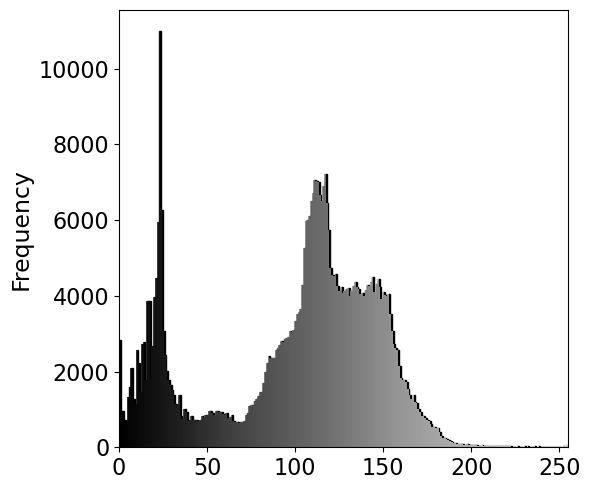

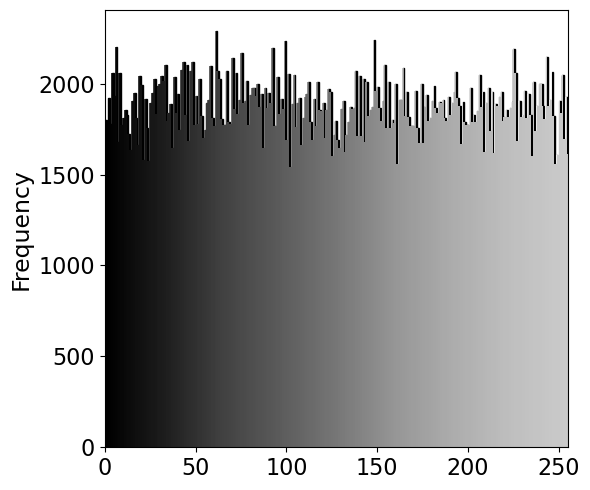

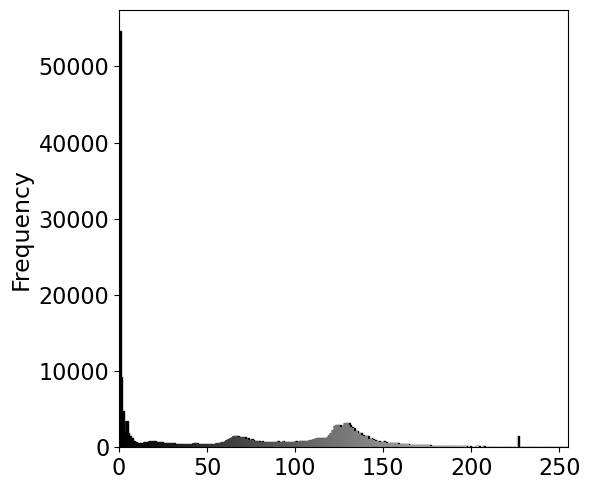

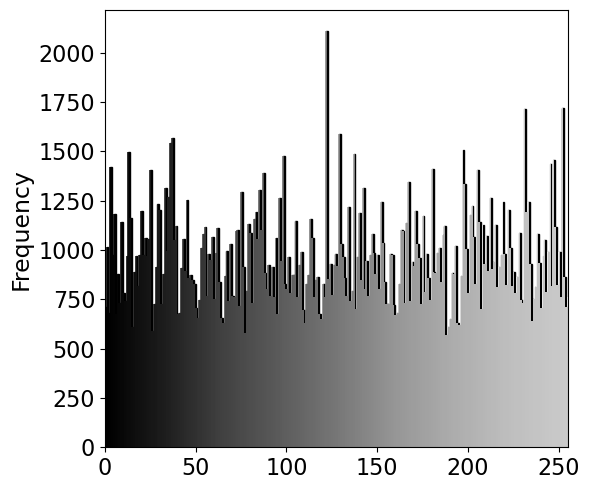

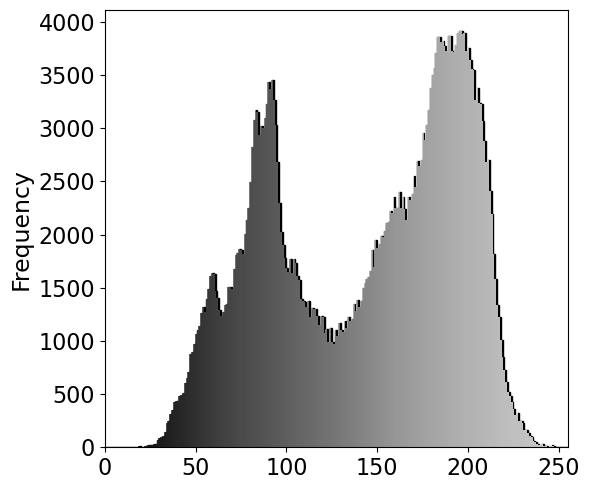

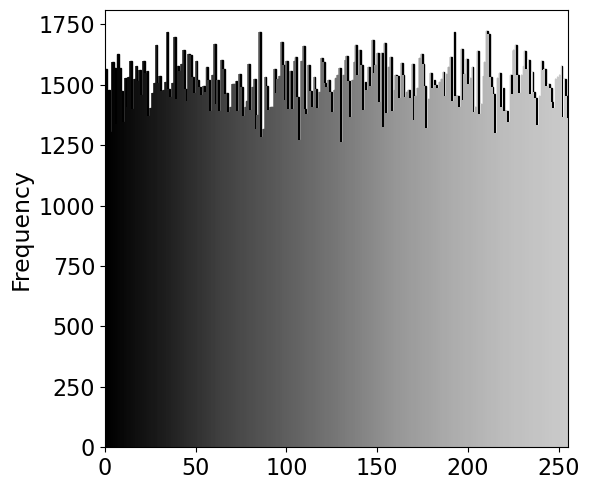

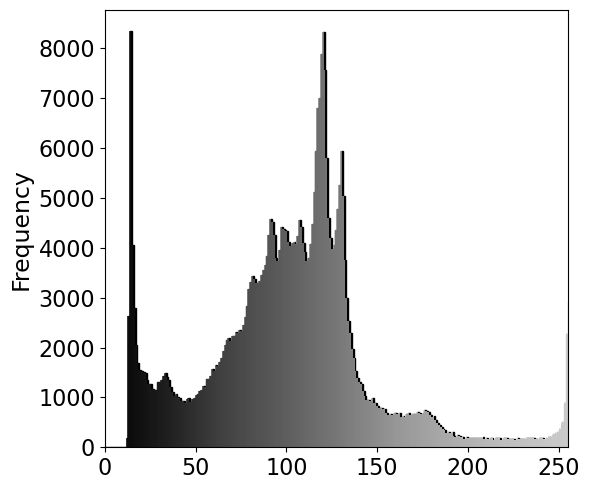

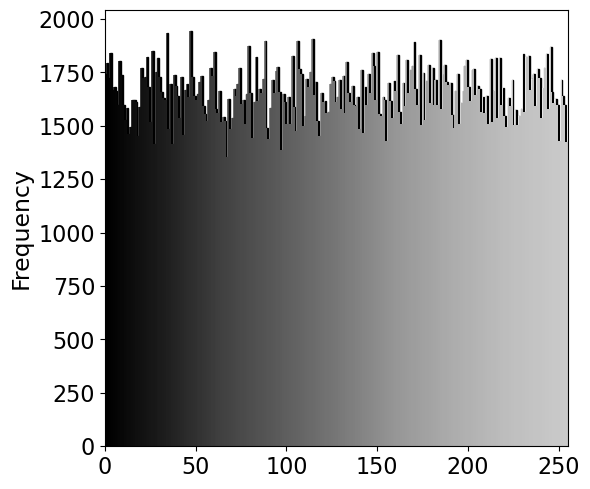

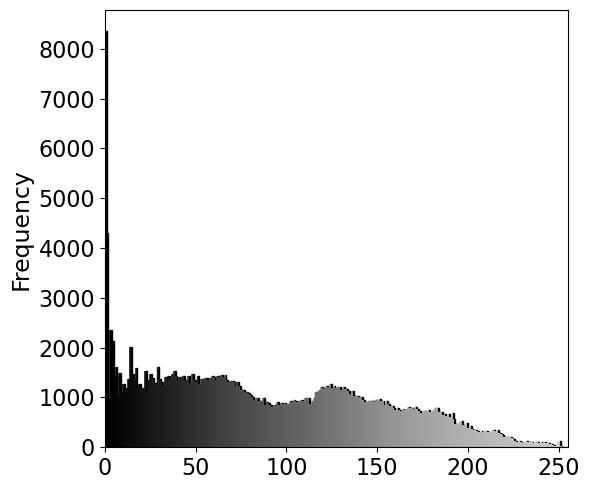

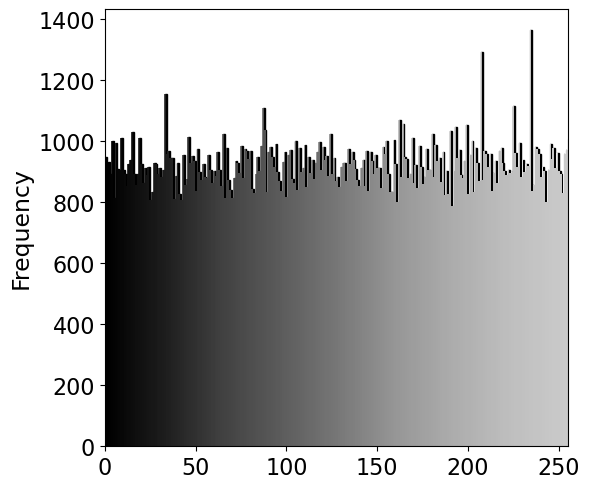

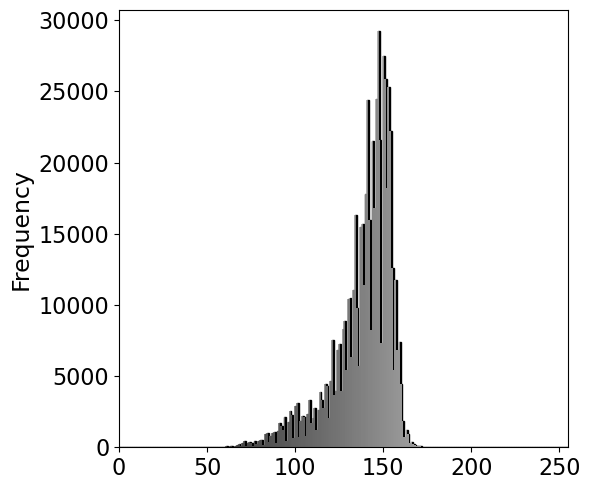

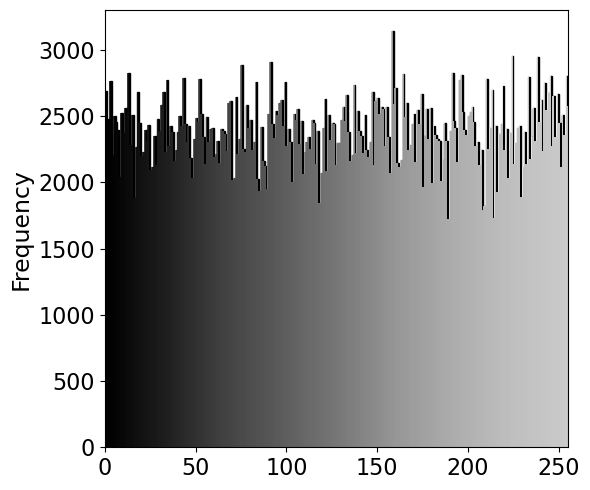

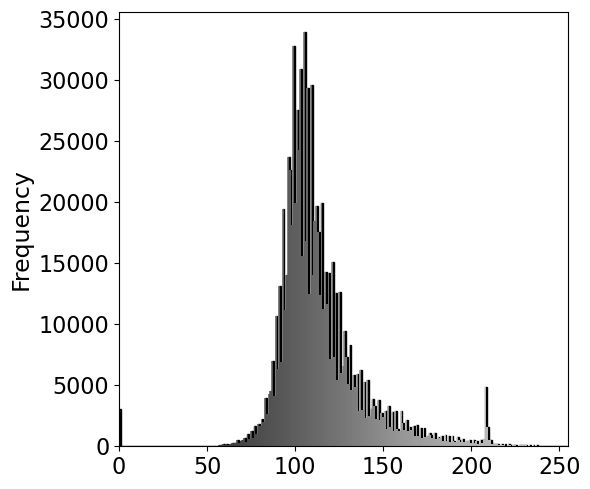

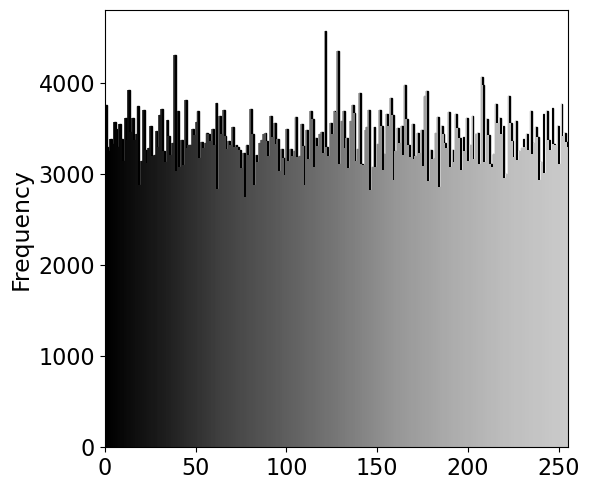

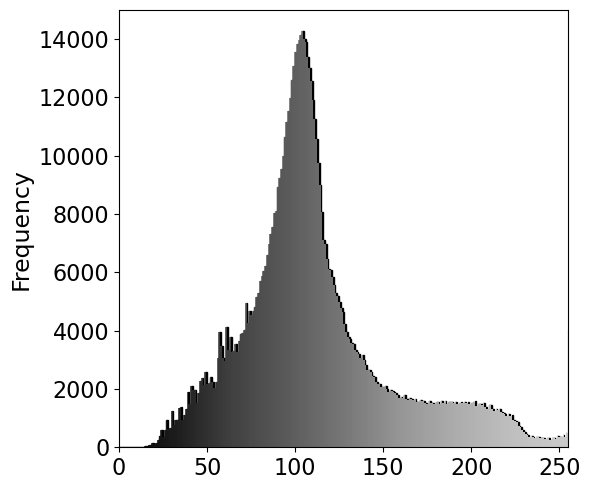

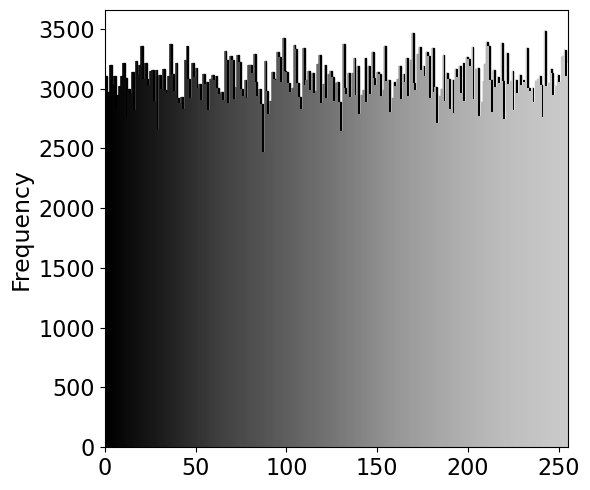

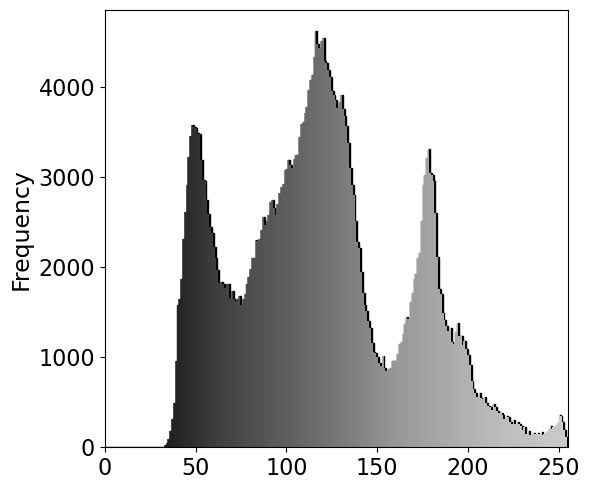

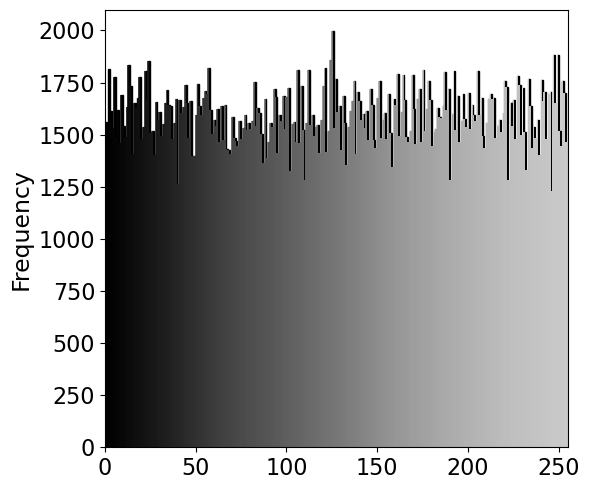

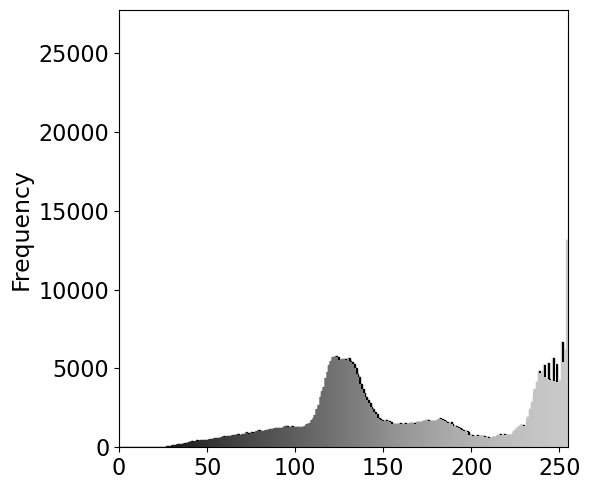

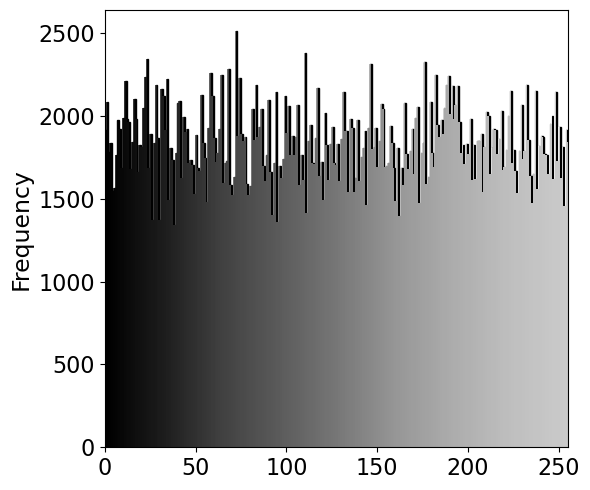

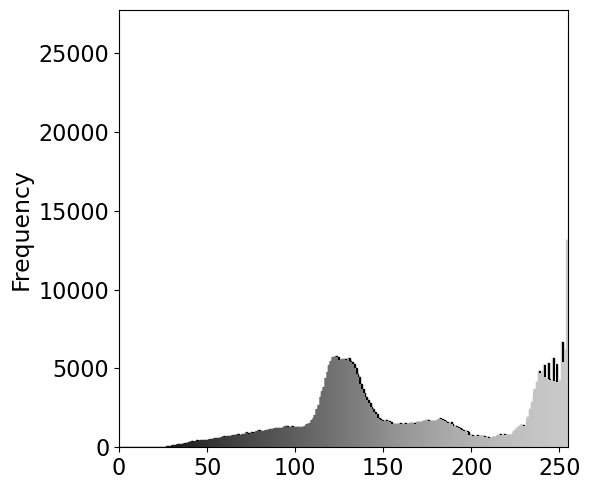

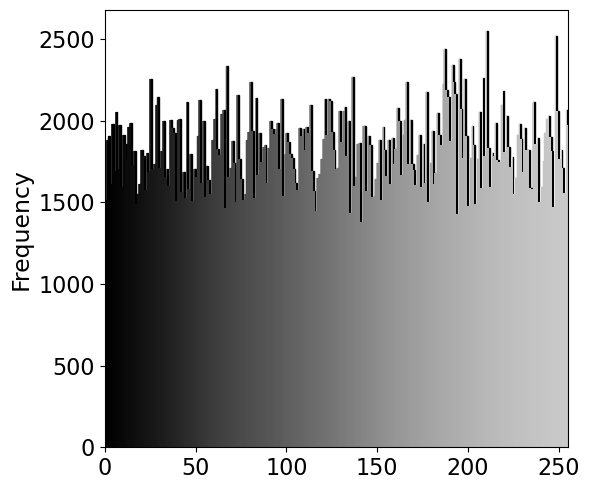

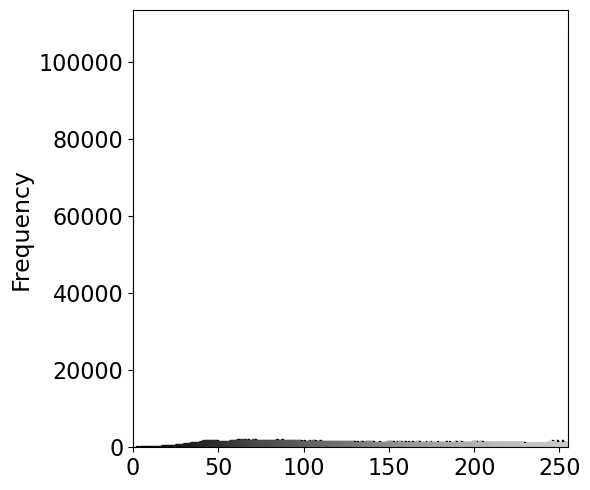

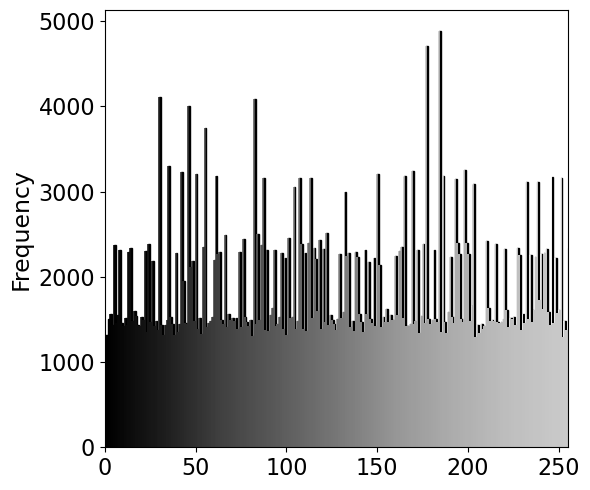

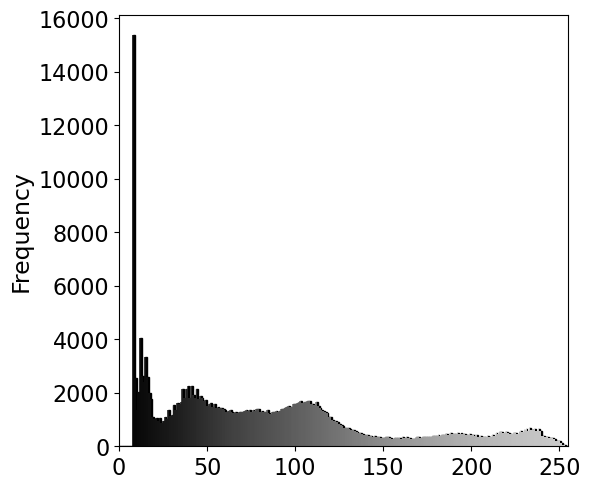

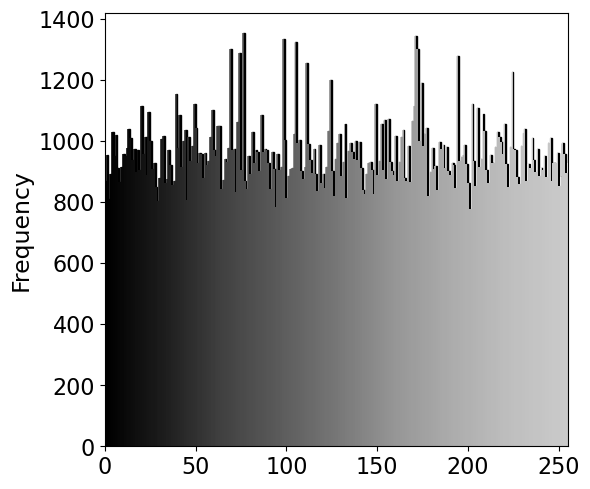

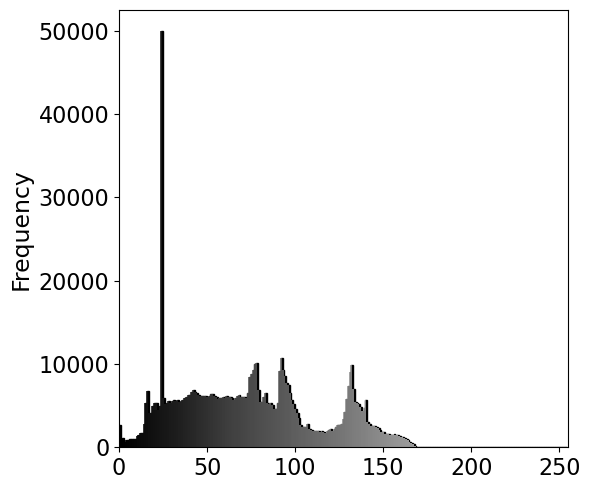

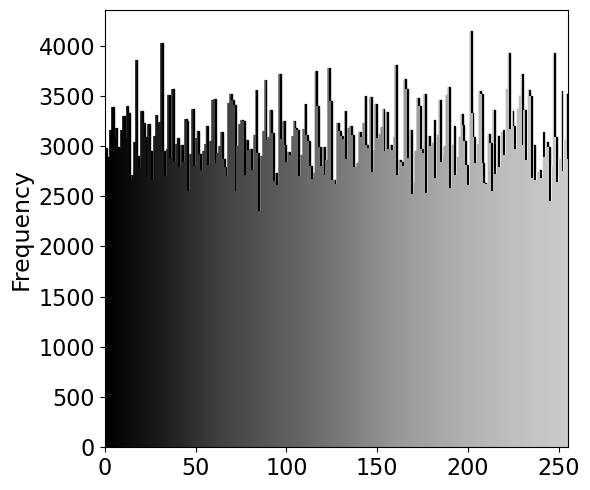

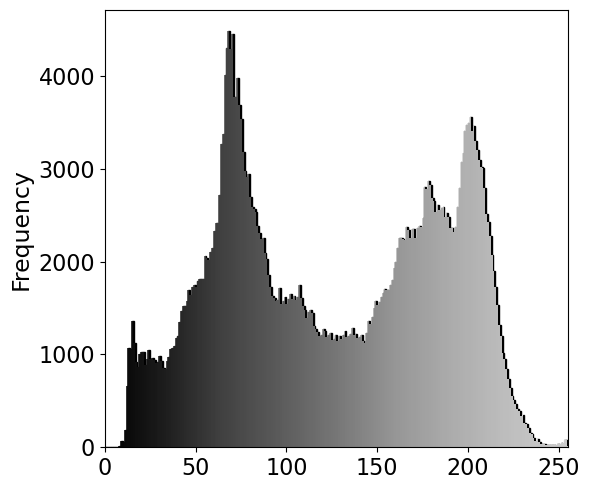

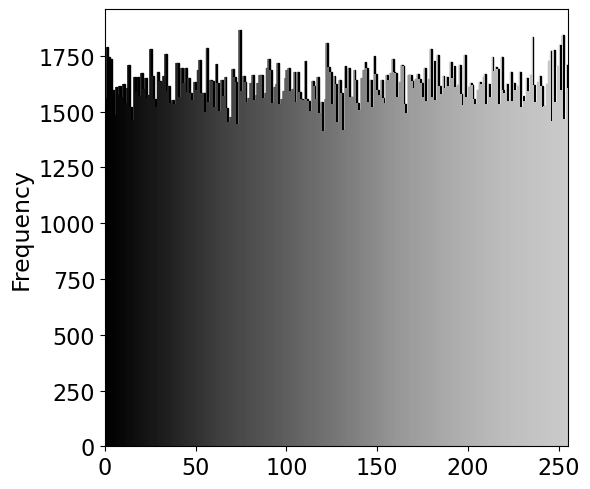

In [3]:
imgs_dir = "/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/freeWciting/BW"



def bunch_testing(source_dir,exper,tosave=0,topng=0,tables=0,toview=0,ciphfunc=ciphers.alberti_cipher):

    # Create the directory              
    if tosave:
        savefolder = source_dir+"_"+exper
        histsavef = source_dir+'/histograms'
        histciphsavef = savefolder+'/histograms'
        try:
            os.mkdir(savefolder)
            print(f"Directory '{savefolder}' created successfully.")
        except FileExistsError:
            print(f"Directory '{savefolder}' already exists.")
        except PermissionError:
            print(f"Permission denied: Unable to create '{savefolder}'.")
            tosave=0
        except Exception as e:
            print(f"An error occurred: {e}")
            tosave=0
        
        try:
            os.mkdir(histsavef)
            print(f"Directory '{histsavef}' created successfully.")
        except FileExistsError:
            print(f"Directory '{histsavef}' already exists.")
        except PermissionError:
            print(f"Permission denied: Unable to create '{histsavef}'.")
            tosave=0
        except Exception as e:
            print(f"An error occurred: {e}")
            tosave=0

        try:
            os.mkdir(histciphsavef)
            print(f"Directory '{histciphsavef}' created successfully.")
        except FileExistsError:
            print(f"Directory '{histciphsavef}' already exists.")
        except PermissionError:
            print(f"Permission denied: Unable to create '{histciphsavef}'.")
            tosave=0
        except Exception as e:
            print(f"An error occurred: {e}")
            tosave=0
        
        # Iterate over files in current directory

    avg=0

    imgsfiles = list(set(glob(source_dir+"/*")))# - set(glob(imgs_dir+"/*.rtf")))

    for file in imgsfiles:
        # img_filename = os.path.join(source_dir,file)
        if os.path.isfile(file):
            imgg = Image.open(file)
            imggarr = np.array(imgg)
        
        
        startT = time.time()
        imgSBarr = ciphfunc(imgg)
        endT = time.time()
        avg += endT-startT
        print(endT-startT)
        imgEnc = Image.fromarray(imgSBarr).convert('L')


        fname = file.split('/')[-1]
        fname = fname.split('.')[0]
        print(fname)
        
        if toview:
            hist1,hist2 = ciphers.plot_image_and_histogram(np.array(imgg))
            newhist1,newhist2 = ciphers.plot_image_and_histogram(imgEnc)

        if tables:
            ogentr = ciphers.calculate_image_entropy(imgg)
            
            entr = ciphers.calculate_image_entropy(imgEnc)
            print("Entropia, Correlacion H, V, D:") 
            corr = ciphers.calculate_pixel_correlation(imgg)
            print(f"{corr['Horizontal']} & {corr['Vertical']} & {corr['Diagonal']} & {ogentr} "+"\\")
            print("Cipher Entropia, Correlacion H, V, D:") 
            corr = ciphers.calculate_pixel_correlation(imgEnc)
            print(f"  {corr['Horizontal']} & {corr['Vertical']} & {corr['Diagonal']} & {entr} "+"\\")
            


            print("NPCR;UACI;MSE;PSNR")
            per_npcr_uaci = ciphers.npcrv_uaci(imgg,imgEnc)
            per_psnr = ciphers.psnr(imgg,imgEnc)
            print(f"{per_npcr_uaci[0]} & {per_npcr_uaci[1]} & {per_psnr[0]} & {per_psnr[1]} "+ "\\")

        if tosave:
            saveroute = savefolder+'/'+exper+fname+'.png'
            oghistroute = histsavef+'/hist'+fname+'.png'
            enchistroute = histciphsavef+'/hist'+exper+fname+'.png'
            # print("hola"+fname)
            # print("hola"+saveroute)
            # print("hola"+oghistroute)
            # print("hola"+enchistroute)
            imgEnc.save(saveroute,format='PNG')
            ciphers.plot_histogram(imggarr,tosave=oghistroute)
            ciphers.plot_histogram(imgEnc,tosave=enchistroute)
                    
    print(avg/14)

bunch_testing(imgs_dir,'SBxRow',tables=1,tosave=1,ciphfunc=ciphers.alberti_cipher)




# Quick tests!

In [109]:
import numpy as np

def extended_zigzag_scramble(image, zigzag_mode, diag_params):
    M, N = image.shape
    D = M + N - 1  # número total de diagonales

    if len(diag_params) != D - 2:
        raise ValueError(f"Se requieren {D-2} parámetros, pero se recibieron {len(diag_params)}")

    main_diags = []  
    anti_diags = []   

    for k in range(1, D+1):

        const = k - M
        main_pixels = []
        for i in range(1, M+1):
            j = i + const
            if 1 <= j <= N:
                main_pixels.append(image[i-1, j-1])
        main_diags.append(main_pixels)


        anti_pixels = []
        for j in range(1, N+1):
            i = k + 1 - j
            if 1 <= i <= M:
                anti_pixels.append(image[i-1, j-1])
        anti_diags.append(anti_pixels)

    if zigzag_mode == 0:

        diag_info = [(k, anti_diags[k-1]) for k in range(1, D+1)]
    elif zigzag_mode == 1:

        diag_info = [(k, main_diags[k-1]) for k in range(1, D+1)]
    elif zigzag_mode == 2:

        diag_info = [(k, anti_diags[k-1]) for k in range(D, 0, -1)]
    elif zigzag_mode == 3:

        diag_info = [(k, main_diags[k-1]) for k in range(D, 0, -1)]
    else:
        raise ValueError("zigzag_mode debe ser 0, 1, 2 o 3")

    flat_scrambled = []
    for k, diag_list in diag_info:
        n = len(diag_list)

        if 2 <= k <= D-1:
            param = diag_params[k-2]       
            x = (param >> 2) & 1
            y = (param >> 1) & 1
            z = param & 1

            m = (n + 1) // 2                 
            P1 = diag_list[:m]
            P2 = diag_list[m:]

            if y:
                P1 = P1[::-1]                 
            if z:
                P2 = P2[::-1]                 
            if x:
                nueva_diag = P2 + P1           
            else:
                nueva_diag = P1 + P2
            flat_scrambled.extend(nueva_diag)
        else:
    
            flat_scrambled.extend(diag_list)

    scrambled = np.array(flat_scrambled).reshape(M, N)
    return scrambled
baboon_path = "/Users/gaelsegura/Documents/codes/proyectos/research_repos/test_images/baboon512x512.jpg"
baboon_img = Image.open(baboon_path).convert('L')
baboon_arr = np.array(baboon_img)
M, N = np.shape(baboon_arr)
np.random.seed(42)
params = np.random.randint(0, 8, size=(M+N-3)).tolist
scrambled = extended_zigzag_scramble(baboon_arr, zigzag_mode=0, diag_params=params)
ciphers.plot_image_and_histogram(baboon_arr)
ciphers.plot_image_and_histogram(scrambled)

TypeError: object of type 'builtin_function_or_method' has no len()